In [10]:
import ast

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [11]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [12]:
sns.set_context("paper", font_scale=1.25)
sns.set_palette("Set2")

In [13]:
df = pd.read_csv("../data/experiments_results.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,30,Ackley,PSO (JAX),4.622841,"[1.113734483718872, 0.7001715302467346, -0.924...","[19.366552352905273, 19.366552352905273, 19.36...",0.016782
1,30,Ackley,PSO (JAX),2.790190,"[0.05833522975444794, 0.3149930238723755, 0.09...","[20.161170959472656, 20.161170959472656, 20.16...",0.014604
2,30,Ackley,PSO (JAX),3.946033,"[1.7138893604278564, -0.11006215959787369, -0....","[20.594215393066406, 20.294082641601562, 20.29...",0.014545
3,30,Ackley,PSO (JAX),3.115826,"[-1.0325804948806763, -0.07666338980197906, -0...","[19.882823944091797, 19.59520149230957, 19.595...",0.014225
4,30,Ackley,PSO (JAX),2.795540,"[-0.055404067039489746, 0.7828329205513, 0.031...","[19.213329315185547, 18.976797103881836, 18.97...",0.014182


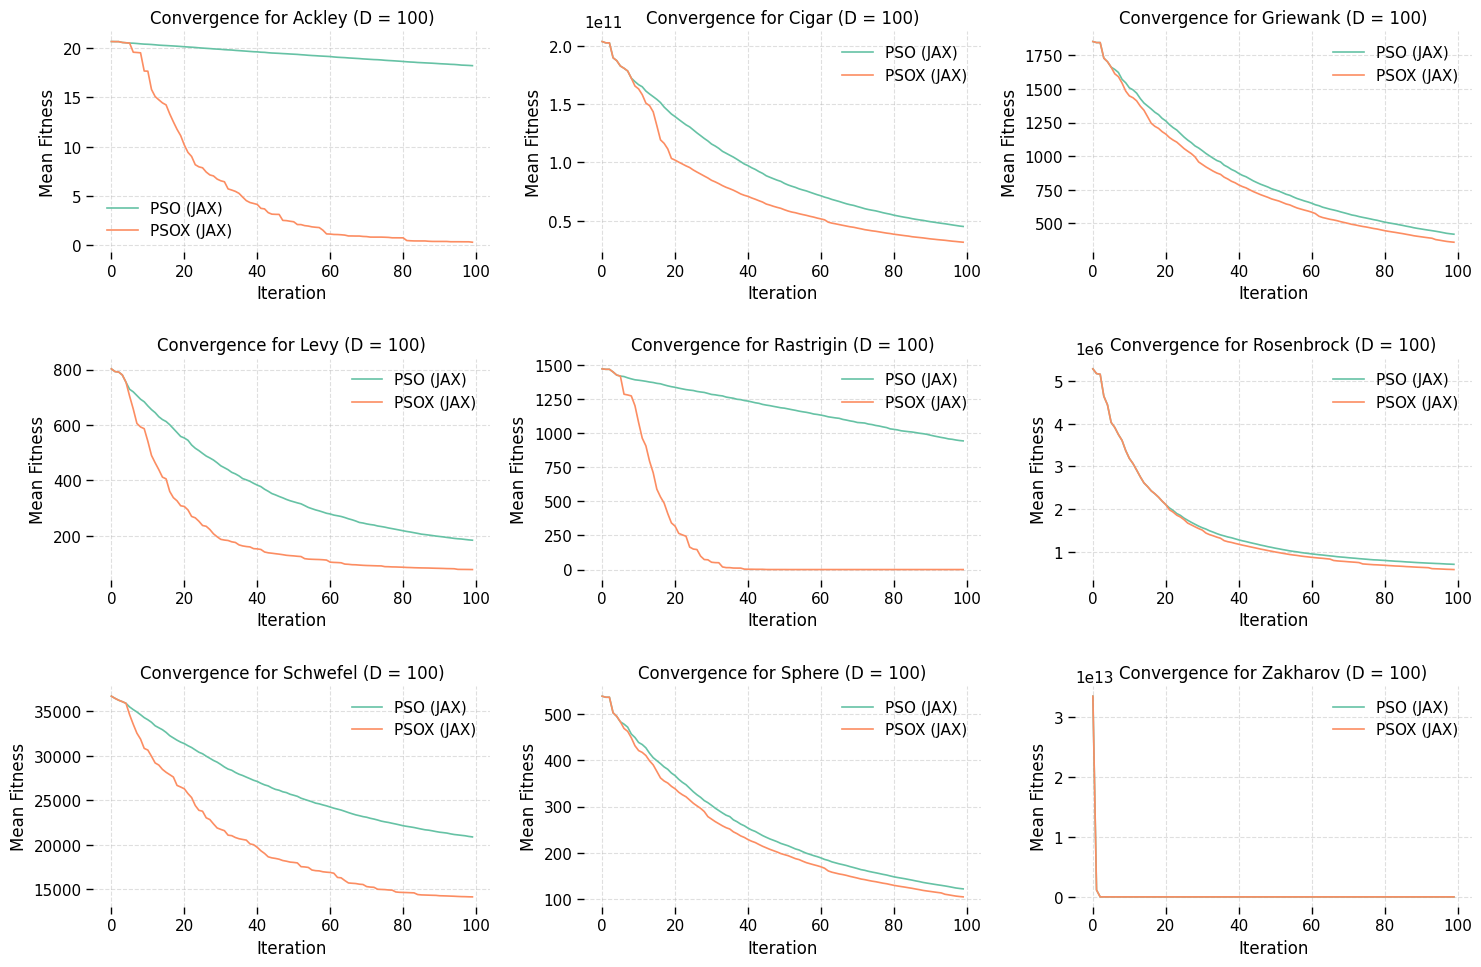

In [ ]:
dimension = 200

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, benchmark in zip(axes, df["benchmark"].unique()):
    subset = df[(df["dimension"] == dimension) & (df["benchmark"] == benchmark)]

    for algorithm in subset["algorithm"].unique():
        alg_subset = subset[subset["algorithm"] == algorithm]
        df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
        mean_fitness = df_fitness.mean()
        sns.lineplot(mean_fitness, label=algorithm, ax=ax)

    ax.set_title(f"Convergence for {benchmark} (D = {dimension})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean Fitness")
    ax.legend(frameon=False)
    sns.despine(ax=ax, left=True, right=True, bottom=True)
    ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../results/convergence_plots.pdf", bbox_inches="tight")
plt.show()

In [15]:
algorithm_a = "PSOX (JAX)"
algorithm_b = "PSO (JAX)"

threshold = 0.05
df_filtered = df[df["algorithm"].isin([algorithm_a, algorithm_b])]

results = []
for benchmark in df_filtered["benchmark"].unique():
    for dimension in df_filtered["dimension"].unique():
        subset = df_filtered[
            (df_filtered["benchmark"] == benchmark)
            & (df_filtered["dimension"] == dimension)
        ]

        fitness_a = subset[subset["algorithm"] == algorithm_a][
            "best_fitness"
        ].to_numpy()
        fitness_b = subset[subset["algorithm"] == algorithm_b][
            "best_fitness"
        ].to_numpy()

        stat, p_value = stats.wilcoxon(fitness_a, fitness_b, alternative="two-sided")

        median_a = np.median(fitness_a)
        median_b = np.median(fitness_b)

        results.append(
            {
                "benchmark": benchmark,
                "dimension": dimension,
                "median_a": np.median(fitness_a),
                "iqr_a": np.percentile(fitness_a, 75) - np.percentile(fitness_a, 25),
                "median_b": np.median(fitness_b),
                "iqr_b": np.percentile(fitness_b, 75) - np.percentile(fitness_b, 25),
                "p-value": p_value,
                "significance": p_value < threshold,
                "-log10(p-value)": -np.log10(p_value),
                "best_algorithm": algorithm_a
                if np.mean(fitness_a) < np.mean(fitness_b)
                else algorithm_b,
            },
        )

df_results = pd.DataFrame(results)
df_results

,benchmark,dimension,median_a,iqr_a,median_b,iqr_b,p-value,significance,-log10(p-value),best_algorithm
0,Ackley,30,2.894279e+00,1.410049e+00,3.297254e+00,7.571034e-01,1.248732e-03,True,2.903531,PSOX (JAX)
1,Ackley,100,0.000000e+00,0.000000e+00,1.834189e+01,1.488090e+00,1.776357e-15,True,14.750470,PSOX (JAX)
2,Ackley,200,0.000000e+00,0.000000e+00,2.034627e+01,1.542320e-01,1.776357e-15,True,14.750470,PSOX (JAX)
3,Ackley,500,0.000000e+00,0.000000e+00,2.083865e+01,8.408070e-02,1.776357e-15,True,14.750470,PSOX (JAX)
4,Cigar,30,1.810788e+07,1.991085e+07,1.860250e+07,2.052803e+07,1.088094e-01,False,0.963333,PSOX (JAX)
5,Cigar,100,3.663545e+10,4.644675e+10,4.278543e+10,1.921465e+10,9.815398e-04,True,3.008092,PSOX (JAX)
6,Cigar,200,6.972363e-21,2.123220e+11,2.232925e+11,3.176097e+10,1.174195e-06,True,5.930260,PSOX (JAX)
7,Cigar,500,2.558790e-24,4.344517e-20,9.879973e+11,5.500810e+10,1.776357e-15,True,14.750470,PSOX (JAX)
8,Griewank,30,1.261466e+00,3.023861e-01,1.284538e+00,2.281024e-01,1.171869e-02,True,1.931121,PSOX (JAX)
9,Griewank,100,3.745746e+02,1.568865e+02,4.063420e+02,1.375775e+02,1.796048e-02,True,1.745682,PSOX (JAX)


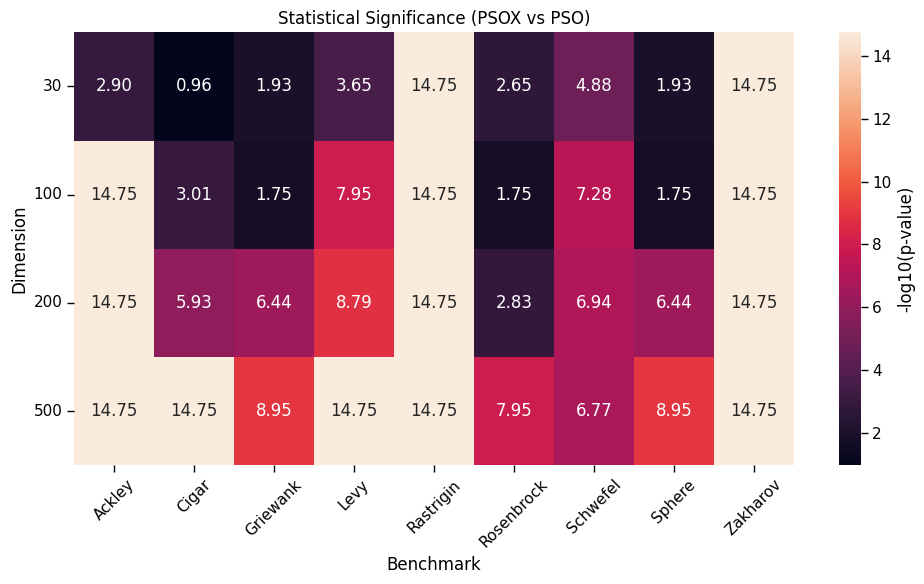

In [16]:
heatmap = df_results.pivot_table("-log10(p-value)", "dimension", "benchmark")
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, annot=True, fmt=".2f", cbar_kws={"label": "-log10(p-value)"})
plt.title("Statistical Significance (PSOX vs PSO)")
plt.xlabel("Benchmark")
plt.ylabel("Dimension")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/significance_heatmap.pdf", bbox_inches="tight")
plt.show()

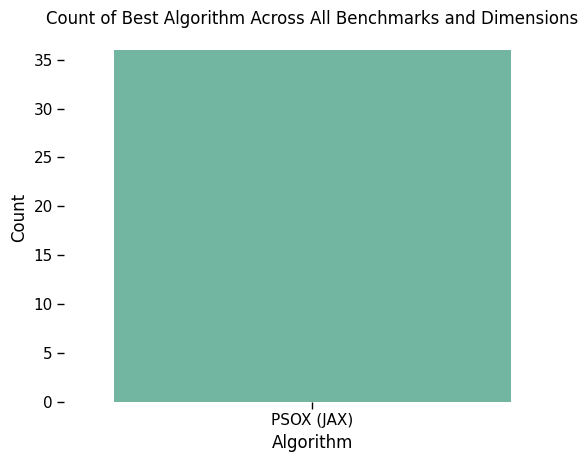

In [17]:
df_count = df_results["best_algorithm"].value_counts().reset_index()
sns.barplot(data=df_count, x="best_algorithm", y="count", hue="best_algorithm")
plt.title("Count of Best Algorithm Across All Benchmarks and Dimensions")
plt.xlabel("Algorithm")
plt.ylabel("Count")
sns.despine(left=True, bottom=True)
plt.savefig("../results/best_algorithm_count.pdf", bbox_inches="tight")
plt.show()

In [18]:
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
# axes = axes.flatten()

# for ax, dimension in zip(axes, df["dimension"].unique()):
#     mean = (
#         df[df["dimension"] == dimension]
#         .groupby(["benchmark", "algorithm"])["execution_time"]
#         .mean()
#     )

#     sns.barplot(
#         x=mean.values,
#         y=mean.index.get_level_values("benchmark"),
#         hue=mean.index.get_level_values("algorithm"),
#         orient="h",
#         ax=ax,
#     )
#     ax.set_title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
#     ax.set_xlabel("Benchmark")
#     ax.set_ylabel("Mean Execution Time (s)")
#     ax.legend(title="Algorithm")
#     ax.tick_params(axis="x", rotation=45)

# plt.tight_layout()
# plt.show()